<a href="https://colab.research.google.com/github/Lanaalkhammash/final_project_Mental_health/blob/main/Mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [ ]:
#• Check the shape (number of rows and columns)
df = pd.read_csv("mental_health_survey_dataset_300k.csv")
df =df.copy()# Create a copy of the dataset to preserve the original data
print(df.shape)
print(df.head())
print(df.columns)
print(df.info())
# Explore the dataset using shape, head, columns, and info
# to better understand the data structure and features

(46119, 20)
                         participant_id  age             gender       country  \
0  5d5158c6-7eea-4ed8-bb28-5afb07836137   58             Female        Canada   
1  518dc525-f8d3-4775-bdbe-d46ef078b37b   50             Female  Saudi Arabia   
2  30118b61-bd27-4e4b-b215-3f146f1de820   31  Prefer not to say         India   
3  25ad1e03-6b10-4d0c-a84e-366768e158aa   54             Female            UK   
4  4126273e-5507-4869-bc90-3ae6104f0cf8   59             Female           USA   

          occupation  work_hours_per_week  screen_time_hours  sleep_hours  \
0            Teacher                   23                9.8          9.2   
1     Data Scientist                   38                6.8          4.9   
2         Freelancer                   54                8.8          8.6   
3  Software Engineer                   39               12.3          5.7   
4            Manager                   58                4.5          9.5   

  sleep_quality exercise_frequency  st

In [ ]:
#• Check for missing values — fill or drop them
print(df.isnull().sum())
# Check for missing values using isnull()
# to identify whether the dataset contains any null values

# The results showed that the dataset does not contain missing values

participant_id                   0
age                              0
gender                           0
country                          0
occupation                       0
work_hours_per_week              0
screen_time_hours                0
sleep_hours                      1
sleep_quality                    1
exercise_frequency               1
stress_score                     1
anxiety_score                    1
depression_score                 1
social_support                   1
therapy_history                  1
family_history_mental_illness    1
academic_or_job_pressure         1
financial_stress_score           1
mental_health_risk               1
survey_date                      1
dtype: int64


In [ ]:
#• Check class balance: are there roughly equal numbers of each label?
df['mental_health_risk'].value_counts()
#• If one class has far more samples than the other, note this and use F1-score as your main metric

,count
mental_health_risk,
High,30165
Moderate,12915
Low,3038


Task 1.2 — Prepare the Data


In [ ]:
df_processed = df.drop(columns=["participant_id", "survey_date"])# Remove unnecessary columns that are not useful for model training

df_processed.dropna(subset=["mental_health_risk"], inplace=True)# Remove rows with missing values in the target column
# to avoid data leakage during model training and prediction

x=df_processed.drop(columns=["mental_health_risk"],axis=1)
y=df_processed["mental_health_risk"]
le=LabelEncoder()
y=le.fit_transform(y)# Select categorical columns containing text data

categorical_cols = x.select_dtypes(include=['object']).columns
x=pd.get_dummies(x,columns=categorical_cols,drop_first=True)# Apply One-Hot Encoding to categorical features
# to convert text values into numerical format
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
# Create a Logistic Regression model
# because the dataset contains multiple classes

model=LogisticRegression(max_iter=1000)
# Train the model using the training data
model.fit(x_train,y_train)
# Generate predictions using the testing data
y_pred=model.predict(x_test)
# Calculate the weighted F1-score
# to evaluate model performance on imbalanced data
F1=f1_score(y_test,y_pred,average='weighted')#وطلعنا ال F1 له
print(F1)

0.7857747149012791


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Task 1.3 — Train and Compare Models


In [ ]:
#• Train at least 3 models: e.g. Logistic Regression, Random Forest, KNN

# Create and train the Random Forest model
random_forest_model = RandomForestClassifier()
random_forest_model.fit(x_train, y_train)
# Generate predictions using Random Forest

y_pred_rf = random_forest_model.predict(x_test)
# Calculate the weighted F1-score for Random Forest


F1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"f1_random_forest:{F1_rf}")
# Create and train the KNN model

knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
# Generate predictions using KNN

y_pred_knn = knn_model.predict(x_test)
# Calculate the weighted F1-score for KNN

F1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(F1_knn)

f1_random_forest:1.0
0.8177942669185851


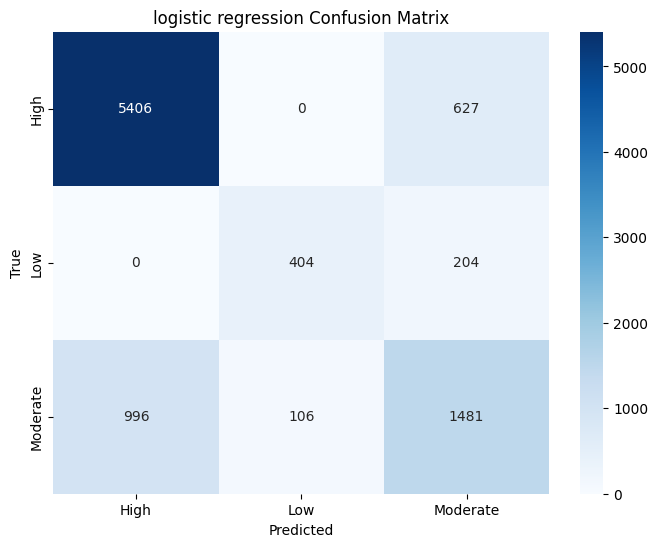

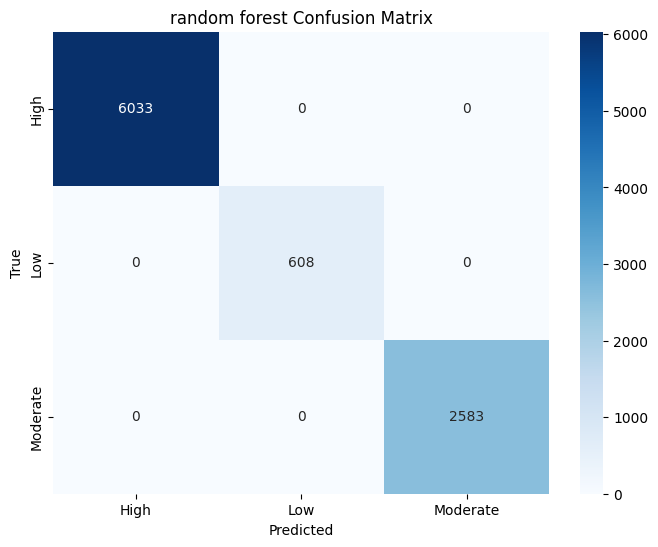

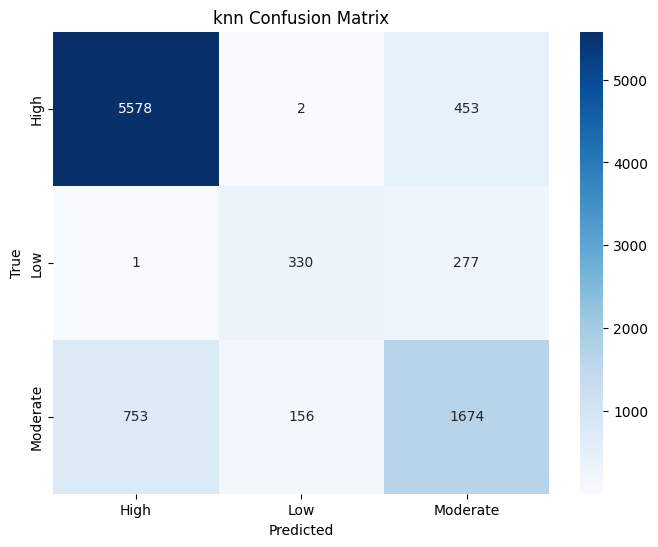

                                    logistic regression  \
f1_score          <function f1_score at 0x7fc02df00860>   
accuracy                                       0.790438   
precision  <function precision_score at 0x7fc02df01080>   
recall        <function recall_score at 0x7fc02df011c0>   

                                          random forest  \
f1_score          <function f1_score at 0x7fc02df00860>   
accuracy                                            1.0   
precision  <function precision_score at 0x7fc02df01080>   
recall        <function recall_score at 0x7fc02df011c0>   

                                                    knn  
f1_score          <function f1_score at 0x7fc02df00860>  
accuracy                                       0.821986  
precision  <function precision_score at 0x7fc02df01080>  
recall        <function recall_score at 0x7fc02df011c0>  


In [ ]:
# Create a loop to evaluate all machine learning models
# using Accuracy, Precision, Recall, and F1-score

summary_results={}
for name ,model in [("logistic regression",model),("random forest",random_forest_model),("knn",knn_model)]:

      # Calculate the weighted F1-score for each model
    # to make model comparison easier
  f1=f1_score(y_test,model.predict(x_test),average='weighted')
  # Calculate Accuracy score

  acc=accuracy_score(y_test,model.predict(x_test))
 # Calculate Precision score

  precision=precision_score(y_test,model.predict(x_test),average='weighted')
  # Calculate Recall score

  recall=recall_score(y_test,model.predict(x_test),average='weighted')
  # Store all evaluation metrics in a dictionary

  summary_results[name]=[f1_score,acc,precision_score,recall_score]
  # Generate the confusion matrix for each model

  cm = confusion_matrix(y_test, model.predict(x_test))
  # Create confusion matrix figure

  plt.figure(figsize=(8, 6))
  # Plot confusion matrix heatmap
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
  # Add axis labels and title

  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.title(f'{name} Confusion Matrix')
  plt.show()
# Convert the results dictionary into a DataFrame
df_summary=pd.DataFrame(summary_results,index=["f1_score","accuracy","precision","recall"])
print(df_summary)

# Step 2: Neural Network



Task 2.1 — Build and Train


In [ ]:
def build_model():
    model = Sequential()
    # Input layer matching the number of features in x_train (40 features)
    model.add(layers.Dense(128, activation='relu',kernel_regularizer=l2(0.001) ,input_shape=(x_train.shape[1],)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu',kernel_regularizer=l2(0.001))) # Additional Dense layer
    model.add(layers.Dropout(0.4)) # Another dropout layer to reduce overfitting
    # Output layer with 3 units for 3 classes and softmax activation
    model.add(layers.Dense(len(le.classes_), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=32, callbacks=[early_stop])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6426 - loss: 1.1145 - val_accuracy: 0.7466 - val_loss: 0.6307
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7329 - loss: 0.6400 - val_accuracy: 0.7795 - val_loss: 0.5594
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7728 - loss: 0.5563 - val_accuracy: 0.8384 - val_loss: 0.4453
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8267 - loss: 0.4462 - val_accuracy: 0.8882 - val_loss: 0.3306
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8520 - loss: 0.3804 - val_accuracy: 0.9154 - val_loss: 0.2650
Epoch 6/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8704 - loss: 0.3442 - val_accuracy: 0.9225 - val_loss: 0.2508
Epoch 7/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8796 - loss: 0.3189 - val_accuracy: 0.8955 - val_loss: 0.2927
Epoch 8/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8884 - loss: 0.3000 - val_accurac

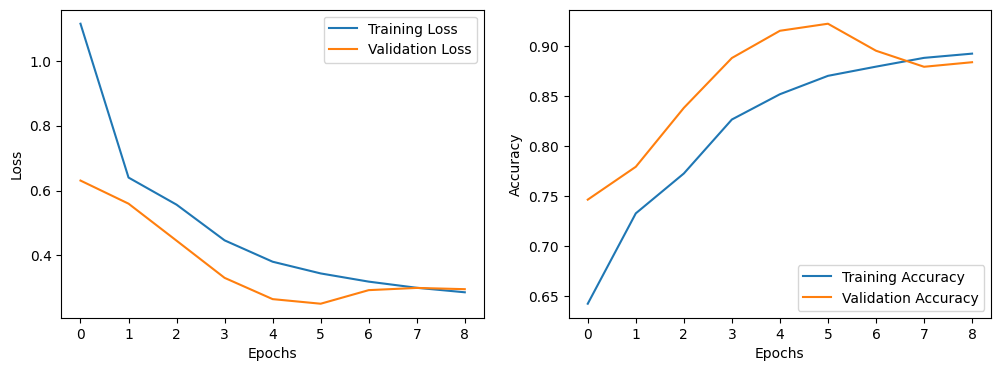

In [ ]:
# Plot the training vs. validation loss and accuracy curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

The Neural Network achieved strong performance and was able to learn complex patterns from the dataset.
It performed better than some machine learning models because it handled the multi-class classification problem more effectively.

However, the Neural Network required more training time compared to Logistic Regression and KNN.